# Importando as Bibliotecas

In [1]:
import pandas as pd
import re

print("Bibliotecas Salvas com Sucesso!!")

Bibliotecas Salvas com Sucesso!!


# Leitura da Base de Dados

In [2]:
dados = pd.read_csv("../data/dataset_tratado.csv", index_col=0)
dados.head()

,review_comment_message,review_score,sentimento
3,Recebi bem antes do prazo estipulado.,5,positivo
4,Parabéns lojas lannister adorei comprar pela I...,5,positivo
9,aparelho eficiente. no site a marca do aparelh...,4,positivo
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positivo
15,"Vendedor confiável, produto ok e entrega antes...",5,positivo


# 1. Pré-Processamento

## Limpando o Texto

In [3]:
CONTRACTIONS = {
    'vc': 'você', 'tb': 'também', 'tbm': 'também', 'pq': 'por que', 'obg': 'obrigado', 'blz': 'beleza',
    'td': 'tudo', 'msm': 'mesmo', 'vlw': 'valeu', 'n': 'não', 'naum': 'não', 'cmprar': 'comprar',
    'mt': 'muito', 'pra': 'para'
}

In [4]:
def limpar_texto(texto):

    # 1. Lowercase
    texto = texto.lower()
    # 2. Remove HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)
    # 3. Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)
    # 4. Remove e-mails
    texto = re.sub(r'\S+@\S+', ' ', texto)
    # 5. Expande contrações
    # Primeiro quebra o texto em palavras (texto.split())
    # Depois troca as contrações no dicionário (CONTRACTIONS)
    # Por fim junta tudo
    palavras = [CONTRACTIONS.get(p,p) for p in texto.split()]
    texto = ' '.join(palavras)

    # 6. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéêèíìîóôõöúùûüç\s.,!?]', ' ', texto)

    # 7. Normaliza espaços
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

In [5]:
# Fazendo um teste da função
teste = "<p>ADOREI o produto!!! vc precisa comprar tbm https://loja.com</p>"
resultado = limpar_texto(teste)
print(resultado)

adorei o produto!!! você precisa comprar também


In [6]:
dados['texto_limpo'] = dados['review_comment_message'].apply(limpar_texto)
dados.head()

,review_comment_message,review_score,sentimento,texto_limpo
3,Recebi bem antes do prazo estipulado.,5,positivo,recebi bem antes do prazo estipulado.
4,Parabéns lojas lannister adorei comprar pela I...,5,positivo,parabéns lojas lannister adorei comprar pela i...
9,aparelho eficiente. no site a marca do aparelh...,4,positivo,aparelho eficiente. no site a marca do aparelh...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positivo,"mas um pouco ,travando...pelo valor ta boa."
15,"Vendedor confiável, produto ok e entrega antes...",5,positivo,"vendedor confiável, produto ok e entrega antes..."


## Tokenização - Quebrando texto em unidades

In [7]:
import nltk
from nltk.corpus import stopwords

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

from nltk.tokenize import word_tokenize

In [8]:
STOP_WORDS_PT = set(stopwords.words('portuguese'))

NEGACOES = {"não", "nao", "nunca", "nem", "sem"}

STOP_WORDS_PT = STOP_WORDS_PT - NEGACOES

In [9]:
modelo = "Eu sou cientista de dados"

tokens = word_tokenize(modelo, language="portuguese")
print(tokens)

['Eu', 'sou', 'cientista', 'de', 'dados']


In [10]:
def tokenizacao(texto):

    return word_tokenize(texto, language="portuguese")

In [11]:
dados["tokens"] = dados["texto_limpo"].apply(tokenizacao)

dados[["texto_limpo", "tokens"]].head()

,texto_limpo,tokens
3,recebi bem antes do prazo estipulado.,"[recebi, bem, antes, do, prazo, estipulado, .]"
4,parabéns lojas lannister adorei comprar pela i...,"[parabéns, lojas, lannister, adorei, comprar, ..."
9,aparelho eficiente. no site a marca do aparelh...,"[aparelho, eficiente, ., no, site, a, marca, d..."
12,"mas um pouco ,travando...pelo valor ta boa.","[mas, um, pouco, ,, travando, ..., pelo, valor..."
15,"vendedor confiável, produto ok e entrega antes...","[vendedor, confiável, ,, produto, ok, e, entre..."


In [12]:
def remover_stop_words(tokens):
    resultado = []

    for token in tokens:
        if(
            token.isalpha() and token not in STOP_WORDS_PT
        ):
            resultado.append(token)
    return resultado

In [13]:
dados["tokens"] = dados["tokens"].apply(remover_stop_words)

dados[["texto_limpo", "tokens"]].head()

,texto_limpo,tokens
3,recebi bem antes do prazo estipulado.,"[recebi, bem, antes, prazo, estipulado]"
4,parabéns lojas lannister adorei comprar pela i...,"[parabéns, lojas, lannister, adorei, comprar, ..."
9,aparelho eficiente. no site a marca do aparelh...,"[aparelho, eficiente, site, marca, aparelho, i..."
12,"mas um pouco ,travando...pelo valor ta boa.","[pouco, travando, valor, ta, boa]"
15,"vendedor confiável, produto ok e entrega antes...","[vendedor, confiável, produto, ok, entrega, an..."


## Stemming - Reduzindo palavras ao seu radical

In [14]:
from nltk.stem import RSLPStemmer
import nltk
nltk.download("rslp", quiet=True)

True

In [15]:
# exemplo
texto = ['correndo', 'correu', 'estudou', 'participou', 'ganhou']

stemmer_rslp = RSLPStemmer()
for palavras in texto:
    print(stemmer_rslp.stem(palavras))

corr
corr
estud
particip
ganh


In [16]:
def aplicar_stemming(tokens):
    resultado = []

    for token in tokens:
        resultado.append(stemmer_rslp.stem(token))

    return resultado

In [17]:
dados["stemmer"] = dados["tokens"].apply(aplicar_stemming)

dados[["texto_limpo", "tokens", "stemmer"]].head()

,texto_limpo,tokens,stemmer
3,recebi bem antes do prazo estipulado.,"[recebi, bem, antes, prazo, estipulado]","[receb, bem, ant, praz, estipul]"
4,parabéns lojas lannister adorei comprar pela i...,"[parabéns, lojas, lannister, adorei, comprar, ...","[parabém, loj, lannist, ador, compr, internet,..."
9,aparelho eficiente. no site a marca do aparelh...,"[aparelho, eficiente, site, marca, aparelho, i...","[aparelh, efici, sit, marc, aparelh, impress, ..."
12,"mas um pouco ,travando...pelo valor ta boa.","[pouco, travando, valor, ta, boa]","[pouc, trav, val, ta, boa]"
15,"vendedor confiável, produto ok e entrega antes...","[vendedor, confiável, produto, ok, entrega, an...","[vend, confi, produt, ok, entreg, ant, praz]"


In [18]:
def juntar_palavras(textos):

    return " ".join(textos)

In [19]:
dados["dados_juntos"] = dados["stemmer"].apply(juntar_palavras)

dados[["stemmer", "dados_juntos"]].head()

,stemmer,dados_juntos
3,"[receb, bem, ant, praz, estipul]",receb bem ant praz estipul
4,"[parabém, loj, lannist, ador, compr, internet,...",parabém loj lannist ador compr internet segur ...
9,"[aparelh, efici, sit, marc, aparelh, impress, ...",aparelh efici sit marc aparelh impress desinfe...
12,"[pouc, trav, val, ta, boa]",pouc trav val ta boa
15,"[vend, confi, produt, ok, entreg, ant, praz]",vend confi produt ok entreg ant praz


## Pipeline Completo

# 2. Vetorizando Texto

## Divisão do Treinamento

In [24]:
from sklearn.model_selection import train_test_split

In [26]:
df = dados.copy()
df = df[["dados_juntos", "sentimento"]]
df.head()

,dados_juntos,sentimento
3,receb bem ant praz estipul,positivo
4,parabém loj lannist ador compr internet segur ...,positivo
9,aparelh efici sit marc aparelh impress desinfe...,positivo
12,pouc trav val ta boa,positivo
15,vend confi produt ok entreg ant praz,positivo


In [27]:
sentimento = {
    "positivo": 1,
    "negativo": 0
}
df["sentimento"] = df["sentimento"].map(sentimento)

print("Dados únicos do sentimento")
print(df["sentimento"].unique())

Dados únicos do sentimento
[1 0]


In [28]:
X = df["dados_juntos"]
y = df["sentimento"]

In [29]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify=y, random_state=42, test_size=0.3)

print(f"Dados Treino -> {len(X_treino)}")
print(f"Dados Teste -> {len(X_teste)}")

Dados Treino -> 26194
Dados Teste -> 11226


## TF-IDF

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.85,
    max_features=10000,
    sublinear_tf=True
)

In [32]:
X_tfidf = vectorizer.fit_transform(X_treino)
print(X_tfidf.shape)

(26194, 5755)


In [34]:
feature_names = vectorizer.get_feature_names_out()

print(f"Quantidade de features: {len(feature_names)}")
print(feature_names[:50])

Quantidade de features: 5755
['ab' 'abaix' 'abajur' 'abenço' 'abert' 'aborrec' 'abr' 'abr caix'
 'abr embal' 'abr produt' 'abr reclam' 'abraç' 'abril' 'absurd' 'acab'
 'acab bem' 'acab boa' 'acab bom' 'acab cheg' 'acab compr' 'acab entreg'
 'acab não' 'acab perfeit' 'acab produt' 'acab receb' 'acab recom'
 'acab ruim' 'aceit' 'acend' 'acert' 'acess' 'acessóri' 'ach' 'ach absurd'
 'ach bem' 'ach bom' 'ach car' 'ach demor' 'ach dev' 'ach entreg'
 'ach falt' 'ach fret' 'ach loj' 'ach mater' 'ach melhor' 'ach não'
 'ach pequen' 'ach pod' 'ach pouc' 'ach produt']


In [35]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

doc = X_tfidf[0].toarray().flatten()

top_idx = np.argsort(doc)[-10:][::-1]

for i in top_idx:
    if doc[i] > 0:
        print(f"{feature_names[i]:20} {doc[i]:.3f}")

med não              0.336
fiq med              0.331
compr fiq            0.320
ia                   0.300
env                  0.295
devolv dinh          0.285
faz compr            0.280
med                  0.245
dinh                 0.210
devolv               0.210


In [37]:
media_tfidf = np.asarray(
    X_tfidf.mean(axis=0)
).flatten()

top_idx = media_tfidf.argsort()[-20:][::-1]

top_features = feature_names[top_idx]
top_values = media_tfidf[top_idx]

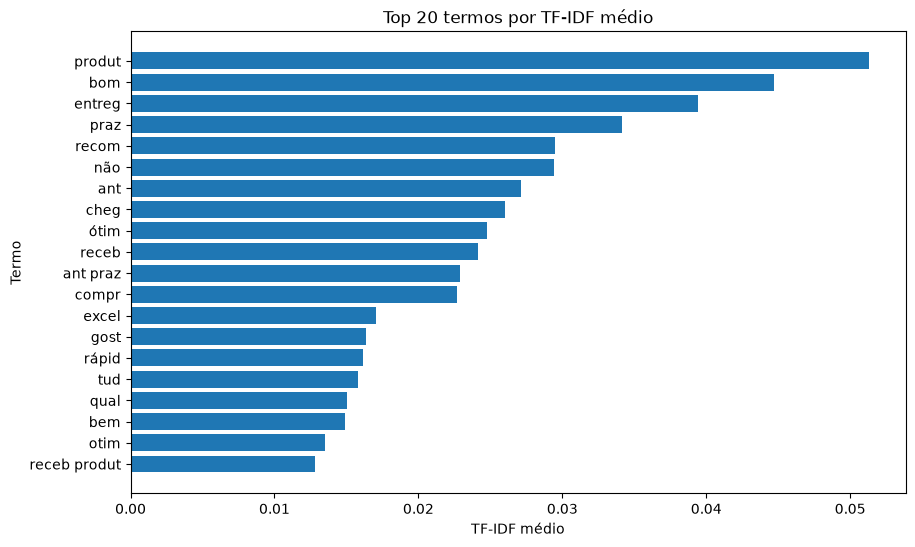

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_features[::-1],
    top_values[::-1]
)

plt.xlabel("TF-IDF médio")
plt.ylabel("Termo")
plt.title("Top 20 termos por TF-IDF médio")

plt.show()